In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sph import integrate, animate_particles, get_density_grid

In [2]:
np.random.seed(0)

no_particles = 300#990
no_steps = 100
L = 10
h = 1#0.5
v_th = 1 # initial random velocities of particles
v0 = 10 # initial flow speed
dt = 0.0001 #0.01 # timestep
c_s = 100#0.1 #speed of sound
gamma = 7
mi = 1

rho0 = no_particles*mi/L**2 # Set equilibrium density to the mean density

central_object = {"radius": 1,
          "boundary_width": 0.1,
          "max_force": 10000}

# Initialize random positions and velocities
initial_positions = np.random.random(size=(no_particles,2))*L
initial_velocities = np.random.normal(size=(no_particles,2))*v_th
initial_velocities[:,0] += v0

mask = np.sqrt((initial_positions[:,0]-L/2)**2+(initial_positions[:,1]-L/2)**2) > (central_object["radius"]+central_object["boundary_width"])
initial_positions = initial_positions[mask]
initial_velocities = initial_velocities[mask]

masses = np.array([mi]*len(initial_positions))


In [3]:
rerun_sim = True

if rerun_sim == True:
    positions, velocities = integrate(initial_positions, initial_velocities, masses, L, h, c_s, rho0, dt, no_steps, central_object=central_object)
    np.savez("flow_sim", positions=positions, velocities=velocities)
else:
    data = np.load("flow_sim.npz")
    positions = data["positions"]
    velocities = data["velocities"]

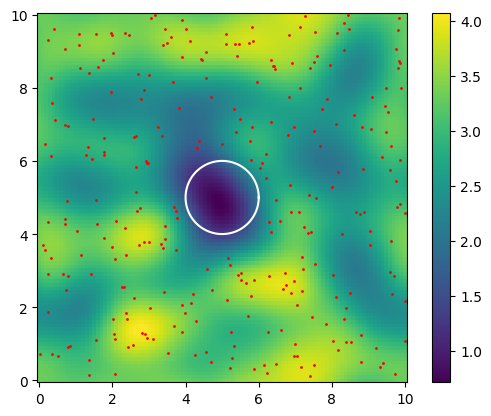

In [4]:
fig, ax = plt.subplots()
idx = -1

is_ghost = np.zeros(len(initial_positions), dtype=bool)

x,y,rho = get_density_grid(positions[idx],masses,L,h,is_ghost=is_ghost)
im = ax.pcolor(x,y,rho)
ax.scatter(positions[idx,~is_ghost,0], positions[idx,~is_ghost,1], s=1, color="red")
ax.scatter(positions[idx,is_ghost,0], positions[idx,is_ghost,1], s=1, color="white")
ax.set_aspect("equal")
theta = np.linspace(0,2*np.pi,100)
ax.plot(L/2+central_object["radius"]*np.cos(theta),L/2+central_object["radius"]*np.sin(theta),color="white")
fig.colorbar(im, ax=ax)
plt.show()

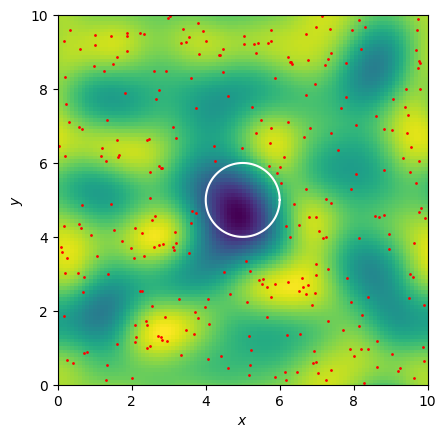

Animation saved to media/flow_animation.mp4!140


In [ ]:
animate_particles(positions[::10], velocities, masses, L, h, fps=10, central_object=central_object, field="velocity", file_name="figures/flow_animation.mp4")

### Check mass conservation
The mass from integrating the density is slighly smaller than the summed particle masses, since the density grid only takes into account the density from the nearest image of a particle. Since our kernel is gaussian, and thus extends infinitely, there are other images of the particle that still give non-zero  integrated density 

In [6]:
from sph import get_density_grid

grid_size = 100
dV = (L/grid_size)**2 # volume element
x,y,rho = get_density_grid(positions[0], masses, L, h, grid_size=grid_size)

print(f"Integrated density =  {np.sum(rho*dV):.2f}")
print(f"Summed particle masses = {np.sum(masses):.2f}")

Integrated density =  288.91
Summed particle masses = 288.00


### Energy conservation

In [7]:

# Assume 'velocities' is your (100, 990, 2) array
# All particles have mass = 1


# Total mass (scalar)
M = np.sum(masses)

# Pre-allocate arrays
E_bulk = np.zeros(no_steps)
E_rand = np.zeros(no_steps)
E_kinetic = np.zeros(no_steps)
E_total = np.zeros(no_steps)
E_object = np.zeros(no_steps)

for t in range(no_steps):
    v = velocities[t]                      # Shape: (990, 2)
    
    # Total momentum: sum of m_i * v_i
    momentum = np.sum(masses[:, None] * v, axis=0)  # Shape: (2,)
    
    # Mean velocity (bulk flow)
    v_mean = momentum / M                  # Shape: (2,)
    
    # Bulk kinetic energy
    E_bulk[t] = 0.5 * M * np.dot(v_mean, v_mean)
    
    # Potential energy from central object
    distances = np.sqrt((positions[t][:,0]-L/2)**2+(positions[t][:,1]-L/2)**2)
    E_object[t] = np.sum(central_object["max_force"]*central_object["boundary_width"]*np.log(np.exp((central_object["radius"]-distances)/central_object["boundary_width"])+1))

    # Total kinetic energy
    kinetic = 0.5 * masses * np.sum(v**2, axis=1)   # Shape: (990,)
    E_kinetic[t] = np.sum(kinetic)
    
    # Random kinetic energy = total - bulk
    E_rand[t] = E_kinetic[t] - E_bulk[t]

    # Total energy including potential
    E_total[t] = E_kinetic[t] + E_object[t]



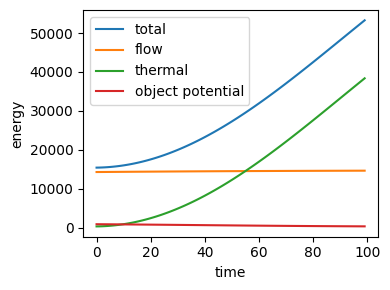

In [8]:
fig, ax = plt.subplots(figsize=(4,3))
ax.plot(E_total, label="total")
ax.plot(E_bulk, label="flow")
ax.plot(E_rand, label="thermal")
ax.plot(E_object, label="object potential")
ax.set_xlabel("time")
ax.set_ylabel("energy")
ax.legend()
fig.tight_layout()
fig.savefig("figures/energy_leapfrog.png", dpi=300)
plt.show()

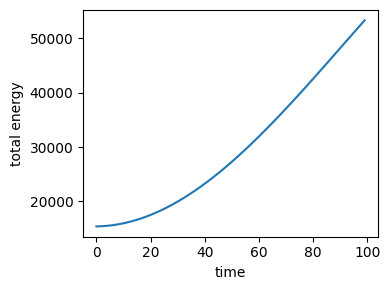

initial = nan +/- nan
final = 29606.1 +/- 1181.9


/home/nielssw/compphysenv2/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nielssw/compphysenv2/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/nielssw/compphysenv2/lib/python3.12/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/nielssw/compphysenv2/lib/python3.12/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/nielssw/compphysenv2/lib/python3.12/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [9]:
fig, ax = plt.subplots(figsize=(4,3))
ax.plot(E_total)
ax.set_xlabel("time")
ax.set_ylabel("total energy")
fig.tight_layout()
fig.savefig("figures/total_energy_leapfrog.png", dpi=300)
plt.show()


print(f"initial = {np.mean(E_total[100:200]):.1f} +/- {np.std(E_total[100:200])/np.sqrt(100):.1f}")
print(f"final = {np.mean(E_total[-100:]):.1f} +/- {np.std(E_total[-100:])/np.sqrt(100):.1f}")

### Drag on object
Epstein drag of fluid particles on an object is given by
$$
F=\frac{4}{3}\rho A v_\mathrm{th}v
$$
Which we can write as
$$
\frac{\mathrm{d}v}{\mathrm{d}t}=-kv
$$
with
$$
k \equiv \frac{4\rho A v_\mathrm{th}}{3m}
$$
with $m$ the object's mass, $\rho$ the fluid density, $A$ the object frontal surface area, and $v_\mathrm{th}$ the thermal velocity of particles. We can easily solve this equation by writing
$$
\frac{\mathrm{d}v}{v}=-k\mathrm{d}t
$$
so we get
$$
v=v_0 e^{-kt}
$$
In our simulation, the density $\rho$ is equivalent to a surface density $\sigma$ divided over an imaginary depth $d$, while the surface area is the diameter of the object $D$ times this same depth, so we get $\rho A=\frac{\sigma}{D}dD=\sigma D$. Now since we are not slowing down the object, but the flow itself, the mass of the object is the total mass of the fluid, which we now can call $m$. Therefore the surface density is $\sigma=m/L^2$ with $L$ the size of the simulation. Using all of this we get
$$
k=\frac{4Dv_\mathrm{th}}{3L^2}
$$

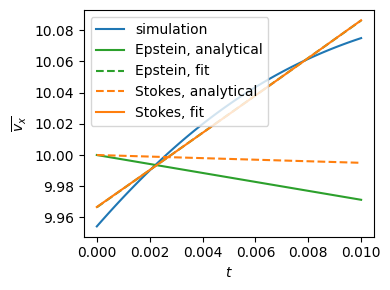

Epstein fit MSE: 3.0e-05
Stokes fit MSE: 3.1e-05


In [10]:
vx = np.mean(velocities[:,:,0], axis=1)

def v_stokes(t, k, v0):
    return v0/(1+k*v0*t)

def v_epstein(t, k, v0):
    return v0*np.exp(-k*t)

from scipy.optimize import curve_fit

tf = dt*no_steps
t = np.linspace(0,tf,no_steps)
D = 2*0.5 # diameter of the object
v_th = np.mean(np.abs(velocities[-1]))
k = 4*D*v_th/(3*L**2)


fig, ax = plt.subplots(figsize=(4,3))
ax.plot(t, vx, label="simulation")

k_epstein = 8*central_object["radius"]*v_th/(3*L**2)
ax.plot(t, v_epstein(t, k_epstein, v0), color="C2", label="Epstein, analytical")

popt_epstein, pcov = curve_fit(v_epstein, t, vx)
ax.plot(t, v_epstein(t,*popt_epstein), color="C2", linestyle="--", label=f"Epstein, fit")

k_stokes = 0.5*central_object["radius"]/L**2
ax.plot(t,v_stokes(t,k_stokes, v0), color="C1", linestyle="--", label="Stokes, analytical")

popt_stokes,pcov = curve_fit(v_stokes, t, vx)
ax.plot(t,v_stokes(t,*popt_stokes), color="C1", label=f"Stokes, fit")

ax.set_xlabel("$t$")
ax.set_ylabel("$\\overline{v_x}$")
ax.legend()
fig.tight_layout()
fig.savefig("figures/draggg.png", dpi=300)
plt.show()

print(f"Epstein fit MSE: {np.mean((vx - v_epstein(t, *popt_epstein))**2):.1e}")
print(f"Stokes fit MSE: {np.mean((vx - v_stokes(t, *popt_stokes))**2):.1e}")


In [11]:


def v_stokes(t, k, v0):
    return v0/(1+k*v0*t)

def v_epstein(t, k, v0):
    return v0*np.exp(-k*t)


tf = dt*no_steps
t = np.linspace(0,tf,no_steps)
vx = np.mean(velocities[:,:,0], axis=1)
interval_size = 200
cd = np.zeros(no_steps-interval_size)

for i in range(no_steps-interval_size-1):
    popt_epstein, pcov = curve_fit(v_epstein, t[i:i+interval_size], vx[i:i+interval_size])
    cd[i] = popt_epstein[0]*L**2/central_object["radius"]

fig, ax = plt.subplots(figsize=(4,3))
ax.plot(t[:-interval_size], cd)
ax.set_xlabel("t")
ax.set_ylabel("$c_\\mathrm{d}$")
fig.tight_layout()
fig.savefig("cd_vs_t_bad.png", dpi=300)
plt.show()

ValueError: negative dimensions are not allowed